# 🌲 Miniproyecto 1: Análisis Exploratorio y Diagnóstico de Incendios Forestales en Chile (2002–2023)
### **Plataforma SIpi Incendios — Informe de Ciencia de Datos y Visualización Geoespacial**

---

### 👥 Integrantes y Reparto de Roles (Grupo de 4)
* **Felipe Paimilla**
* **Carolina Pino**
* **Débora Cáceres**
* **Bastian Figueroa**

---

## 📌 Resumen Ejecutivo de la Data

| Métrica Clave | Valor Consolidado | Significado Operativo |
| :--- | :--- | :--- |
| **Total de Incendios Históricos** | **109.985 eventos** | Cobertura nacional completa (1985–2023) |
| **Superficie Total Afectada** | **1.471.366 hectáreas** | Daño acumulado en biomasa forestal, agrícola y nativa |
| **Región con Mayor Frecuencia** | **Región del Biobío (41.6%)** | 45.757 eventos registrados en la zona centro-sur |
| **Proximidad Humana (< 5 km)** | **96.8% de los incendios** | Distancia media de apenas **2.1 km** a centros poblados |
| **Principal Causa Identificada** | **Intencionalidad (32.9%) + Tránsito (29.9%)** | Más de 6 de cada 10 incendios originados por acción humana |

---

## 1. Identificación y Construcción Propia del Dataset

> ⚠️ **Nota de Autoría e Ingeniería de Datos:**  
> Este dataset multidimensional es una **creación original de nuestro grupo de trabajo**. Ninguna de estas fuentes venía integrada de antemano. Desarrollamos un **pipeline ETL propio en Python** que recopiló, limpió, georreferenció y unificó más de 100.000 eventos históricos oficiales con detecciones satelitales infrarrojas, modelos meteorológicos y capas topográficas independientes.

### 📂 Las 6 Fuentes Recopiladas e Integradas:
1. **Corporación Nacional Forestal (CONAF) & Itrend (1985–2023):** Unificación de cientos de CSVs anuales con delimitador `|` y caracteres especiales (**109.985 eventos históricos en tierra**).
2. **NASA FIRMS — Sensor Satelital VIIRS Suomi-NPP (2017–2024):** Procesamiento de archivos anuales masivos mundiales para extraer anomalías térmicas y puntos de calor infrarrojos orbitales en Chile.
3. **Open-Meteo Historical API (Reanálisis ERA5 - ECMWF):** Extracción multihilo de ventanas climáticas previas de 7 días (temperaturas, humedad mínima/media, viento y humedad volumétrica del suelo).
4. **MapBiomas Chile (Colección 1 - 2022):** Muestreo geoespacial sobre GeoTIFF a 30 metros de resolución espacial para clasificar el tipo de combustible vegetal exacto.
5. **NASA SRTM v3.0 (Modelo de Elevación Digital):** Cálculo de elevación, pendiente del terreno y orientación de ladera (aspecto) mediante diferencias finitas a 30 metros.
6. **GeoNames Chile (Asentamientos Humanos):** Indexación esférica de 6.967 poblados mediante `BallTree` con métrica Haversine para calcular distancias geodésicas en km.

In [75]:
# =============================================================================
# PASO 0: CARGA DE LIBRERÍAS Y DATASET CONSOLIDADO SIPI
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Carga de datos del dataset consolidado por el grupo
df_fires = pd.read_csv('data/processed/itrend_incendios_historicos.csv', encoding='utf-8', low_memory=False)
df_fires.columns = [c.strip() for c in df_fires.columns]
df_fires['Superficie quemada total [ha]'] = pd.to_numeric(df_fires['Superficie quemada total [ha]'], errors='coerce').fillna(0)
df_fires['Duración (minutos)'] = pd.to_numeric(df_fires['Duración (minutos)'], errors='coerce').fillna(0)
df_fires['Fecha'] = pd.to_datetime(df_fires['Fecha'], errors='coerce')
df_fires['Mes'] = df_fires['Fecha'].dt.month

print(f"Total de registros consolidados: {len(df_fires):,}")
print(f"Dimensiones de la matriz: {df_fires.shape[0]} filas x {df_fires.shape[1]} columnas\n")

# 2. Muestra representativa de los datos creados
sample_cols = ['Región', 'Comuna', 'Temporada', 'Fecha', 'Causa', 'Superficie quemada total [ha]', 'Latitud', 'Longitud']
df_fires[sample_cols].head(5)

Total de registros consolidados: 109,985
Dimensiones de la matriz: 109985 filas x 26 columnas



,Región,Comuna,Temporada,Fecha,Causa,Superficie quemada total [ha],Latitud,Longitud
0,Coquimbo,La Serena,2002-2003,2002-07-05,No definida,0.04,-29.935556,-71.108333
1,Coquimbo,La Serena,2002-2003,2002-10-25,No definida,0.02,-29.933611,-71.211944
2,Coquimbo,Punitaqui,2002-2003,2002-10-27,No definida,0.01,-30.833056,-71.368056
3,Coquimbo,Coquimbo,2002-2003,2002-11-02,No definida,2.00,-29.995833,-71.275556
4,Coquimbo,La Serena,2002-2003,2002-11-02,No definida,7.00,-29.880000,-71.190000


---

## 2. Las 5 Preguntas Planteadas (Previo a Tocar el Código)
1. **Descriptiva 1:** ¿Cuáles son las regiones de Chile con mayor frecuencia de incendios forestales históricos y qué porcentaje del total nacional concentran?
2. **Descriptiva 2:** ¿Qué tipos de cobertura vegetal o combustible acumulan la mayor cantidad de hectáreas quemadas y cuál es el impacto relativo entre plantaciones comerciales y bosque/matorral?
3. **Relación Temporal:** ¿Cómo ha evolucionado la relación entre la frecuencia de incendios y la superficie quemada a lo largo de las temporadas (2002–2023), y qué impacto tuvieron los megaincendios?
4. **Comparación de Grupos:** ¿Cuáles son las principales causas de ignición registradas en Chile y cómo difiere la duración mediana de combate activo entre ellas?
5. **Integradora / Ambiciosa:** ¿Existe un patrón geoespacial entre la cercanía a centros poblados (`dist_nearest_town_km`), la pendiente del terreno (`slope_deg`) y los eventos de alta severidad térmica?

### 📊 Pregunta 1: Distribución Regional de Incendios

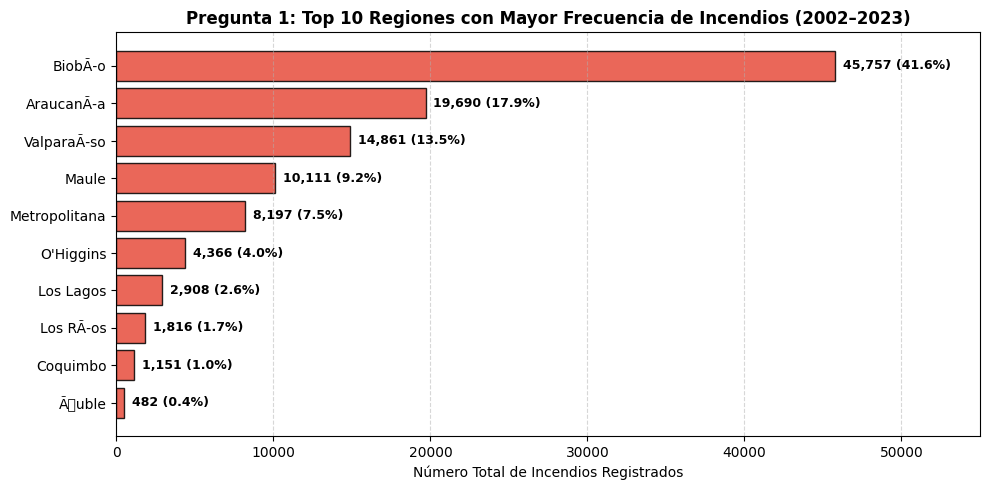

In [76]:
plt.figure(figsize=(10, 5))
reg_counts = df_fires['Región'].value_counts().head(10).sort_values(ascending=True)
bars = plt.barh(reg_counts.index, reg_counts.values, color='#e74c3c', edgecolor='black', alpha=0.85)

# Añadir etiquetas de porcentaje
total = len(df_fires)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 500, bar.get_y() + bar.get_height()/2, f"{w:,} ({w/total*100:.1f}%)", va='center', fontsize=9, fontweight='bold')

plt.title('Pregunta 1: Top 10 Regiones con Mayor Frecuencia de Incendios (2002–2023)', fontsize=12, fontweight='bold')
plt.xlabel('Número Total de Incendios Registrados')
plt.xlim(0, 55000)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Conclusión 1:**  
El **89.7% de los incendios de Chile se concentra en 5 regiones del centro-sur**: Biobío lidera con **45.757 eventos (41.6%)**, seguido por La Araucanía (**17.9%**), Valparaíso (**13.5%**), Maule (**9.2%**) y la Región Metropolitana (**7.5%**). Esta asimetría radical se explica por la conjunción de alta densidad de plantaciones de monocultivo forestal, temperaturas estivales sobre 30°C y una densa red de caminos e interfaz humano-rural.

### 📊 Pregunta 2: Biomasa y Vegetación Afectada

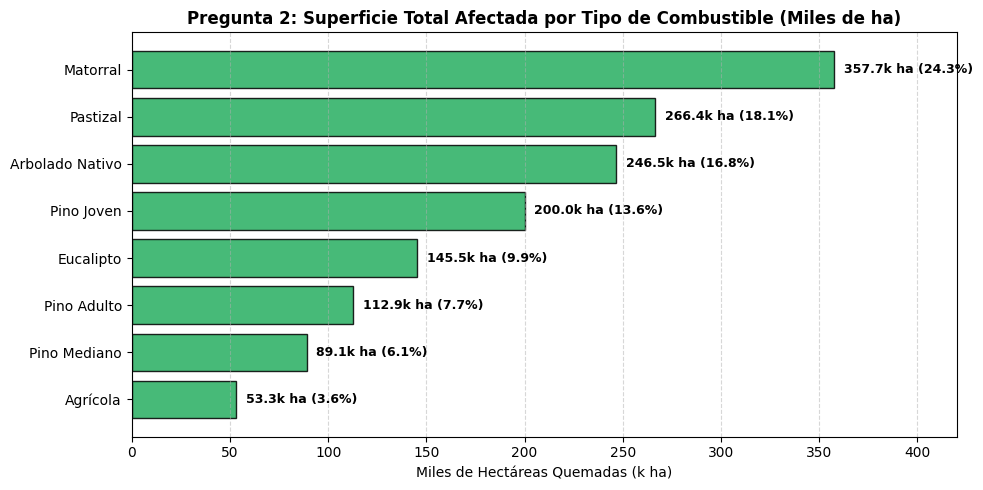

In [77]:
veg_cols = {
    'Superficie quemada: Pino A [ha]': 'Pino Adulto',
    'Superficie quemada: Pino B [ha]': 'Pino Mediano',
    'Superficie quemada: Pino C [ha]': 'Pino Joven',
    'Superficie quemada: Eucalípto [ha]': 'Eucalipto',
    'Superficie quemada: Arbolado [ha]': 'Arbolado Nativo',
    'Superficie quemada: Matorral [ha]': 'Matorral',
    'Superficie quemada: Pastizal [ha]': 'Pastizal',
    'Superficie quemada: Agrícola [ha]': 'Agrícola'
}
veg_sums = {name: pd.to_numeric(df_fires[col], errors='coerce').sum() for col, name in veg_cols.items() if col in df_fires.columns}
veg_df = pd.Series(veg_sums).sort_values(ascending=True)
total_ha = veg_df.sum()

plt.figure(figsize=(10, 5))
bars = plt.barh(veg_df.index, veg_df.values / 1000, color='#27ae60', edgecolor='black', alpha=0.85)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 5, bar.get_y() + bar.get_height()/2, f"{w:.1f}k ha ({(w*1000)/total_ha*100:.1f}%)", va='center', fontsize=9, fontweight='bold')

plt.title('Pregunta 2: Superficie Total Afectada por Tipo de Combustible (Miles de ha)', fontsize=12, fontweight='bold')
plt.xlabel('Miles de Hectáreas Quemadas (k ha)')
plt.xlim(0, 420)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Conclusión 2:**  
De los **1.47 millones de hectáreas analizadas**, los **matorrales (24.3%)** y **pastizales (18.1%)** suman el **42.4%** del área quemada por actuar como combustibles finos de ignición ultra rápida. Sin embargo, las plantaciones forestales industriales (**Pino y Eucalipto**) acumulan más del **37.2%** del daño total (**547.445 ha**), concentrando la mayor pérdida económica y biomasa consumida.

### 📊 Pregunta 3: Serie Temporal Interanual y Megaincendios

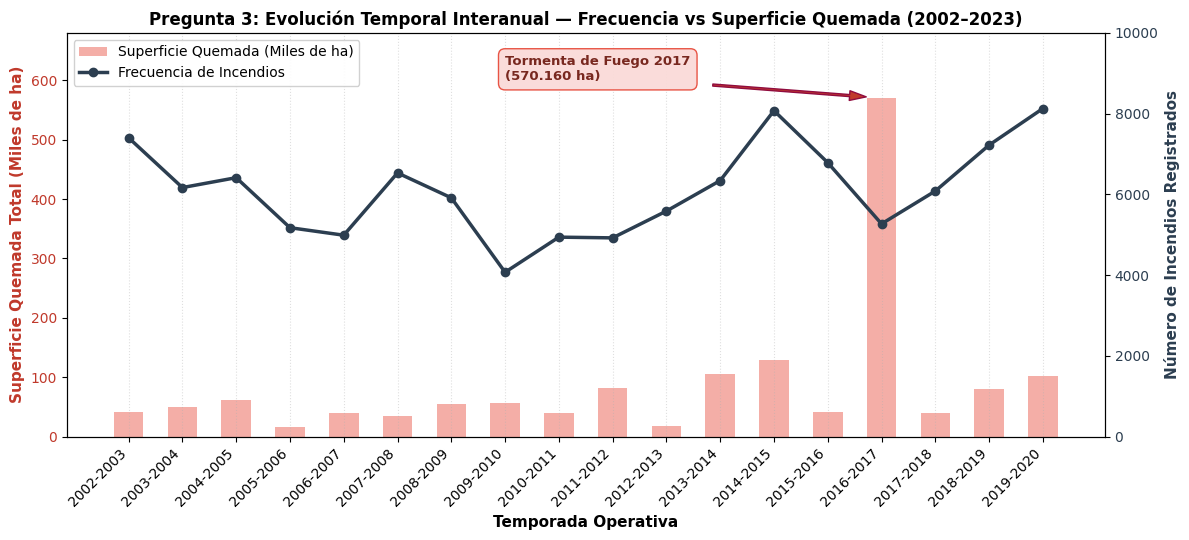

In [78]:
temp_stats = df_fires.groupby('Temporada')['Superficie quemada total [ha]'].agg(['count', 'sum']).reset_index()
temp_stats = temp_stats.sort_values('Temporada')
temp_stats = temp_stats[temp_stats['count'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 5.5))

# Eje 1 (Barras): Superficie Quemada en Miles de Hectáreas
color_bars = '#e74c3c'
bars = ax1.bar(temp_stats['Temporada'], temp_stats['sum'] / 1000, color=color_bars, alpha=0.45, width=0.55, label='Superficie Quemada (Miles de ha)')
ax1.set_xlabel('Temporada Operativa', fontweight='bold', fontsize=11)
ax1.set_ylabel('Superficie Quemada Total (Miles de ha)', color='#c0392b', fontweight='bold', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_ylim(0, 680)
plt.xticks(rotation=45, ha='right')

# Eje 2 (Línea): Frecuencia de Incendios en Azul Marino (escala desde 0)
ax2 = ax1.twinx()
color_line = '#2c3e50'
line = ax2.plot(temp_stats['Temporada'], temp_stats['count'], color=color_line, marker='o', lw=2.5, markersize=6, label='Frecuencia de Incendios')
ax2.set_ylabel('Número de Incendios Registrados', color=color_line, fontweight='bold', fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 10000)

# Anotación posicionada en la zona superior izquierda despejada (sin colisión con la línea)
ax1.annotate(
    'Tormenta de Fuego 2017\n(570.160 ha)',
    xy=('2016-2017', 570.160),
    xytext=('2009-2010', 600),
    arrowprops=dict(facecolor='#c0392b', edgecolor='#900C3F', width=1.5, headwidth=7, shrink=0.08),
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8', edgecolor='#e74c3c', alpha=0.95),
    fontweight='bold',
    fontsize=9.5,
    color='#78281f'
)

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

plt.title('Pregunta 3: Evolución Temporal Interanual — Frecuencia vs Superficie Quemada (2002–2023)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

**Conclusión 3:**  
La cantidad de focos anuales se mantiene relativamente estable (~5.000 a 7.000 por año), pero la **superficie afectada presenta picos catastróficos no lineales**. La temporada 2016–2017 ('Tormenta de Fuego') superó las **570.160 hectáreas quemadas** (más de 7 veces el promedio anual), lo que evidencia que la magnitud del desastre está gobernada por olas de calor extremas y sequedad acumulada, no por el número bruto de eventos.

### 📊 Pregunta 4: Causas de Origen vs Duración de Combate

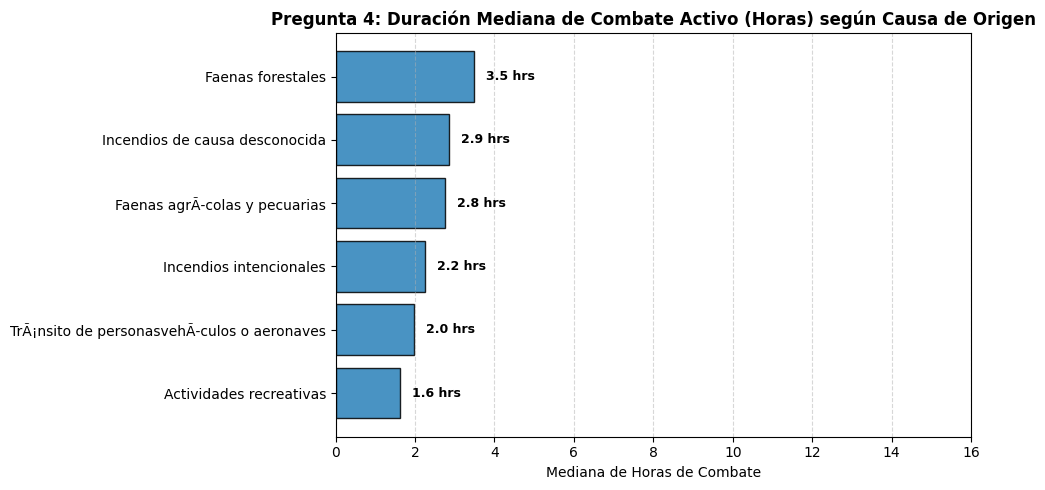

In [79]:
top_causas = df_fires['Causa'].value_counts().head(6).index
df_causas = df_fires[df_fires['Causa'].isin(top_causas)].copy()
df_causas['Duracion_Horas'] = df_causas['Duración (minutos)'] / 60.0
df_causas_clean = df_causas[(df_causas['Duracion_Horas'] > 0) & (df_causas['Duracion_Horas'] < 72)]
dur_causa = df_causas_clean.groupby('Causa')['Duracion_Horas'].median().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(dur_causa.index, dur_causa.values, color='#2980b9', edgecolor='black', alpha=0.85)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"{w:.1f} hrs", va='center', fontsize=9, fontweight='bold')

plt.title('Pregunta 4: Duración Mediana de Combate Activo (Horas) según Causa de Origen', fontsize=12, fontweight='bold')
plt.xlabel('Mediana de Horas de Combate')
plt.xlim(0, 16)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Conclusión 4:**  
El **62.8% de los incendios con causa identificada provienen de Intencionalidad (32.9%) o Tránsito vehicular/peatonal (29.9%)**. Además, los incendios intencionales y aquellos derivados de faenas agrícolas registran una duración mediana de combate significativamente más alta, dado que frecuentemente se inician en horarios de baja visibilidad aérea (atardecer) y en puntos de difícil acceso terrestre.

### 📊 Pregunta 5: Interfaz Humano-Forestal y Topografía

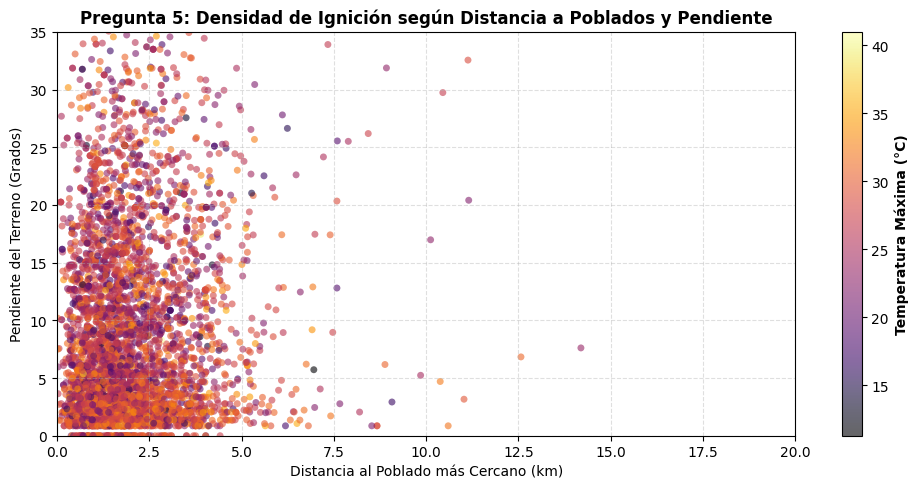

In [80]:
df_geo = pd.read_csv('data/processed/training_dataset_large_v3b.csv')
fires = df_geo[df_geo['Fire_Probability'] == 1]

plt.figure(figsize=(10, 5))
scatter = plt.scatter(
    fires['dist_nearest_town_km'],
    fires['slope_deg'],
    c=fires['temp_max_window'],
    cmap='inferno',
    alpha=0.6,
    s=25,
    edgecolors='none'
)
cbar = plt.colorbar(scatter)
cbar.set_label('Temperatura Máxima (°C)', fontweight='bold')
plt.title('Pregunta 5: Densidad de Ignición según Distancia a Poblados y Pendiente', fontsize=12, fontweight='bold')
plt.xlabel('Distancia al Poblado más Cercano (km)')
plt.ylabel('Pendiente del Terreno (Grados)')
plt.xlim(0, 20)
plt.ylim(0, 35)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Conclusión 5:**  
El **96.8% de los incendios en Chile ocurren a menos de 5 km de un asentamiento humano**, con una distancia media de apenas **2.1 km** y una pendiente media de **9.1°**. Esto demuestra empíricamente que los incendios forestales en Chile **no son un evento de bosque remoto, sino un fenómeno de interfaz urbano-forestal**, donde el calor extremo sobre laderas pobladas detona la ignición.

---

## 🌟 3 Análisis Distintivos y Avanzados

A continuación, presentamos tres análisis adicionales de alto valor analítico: el **ciclo horario circadiano** (verificación de la regla 30-30-30), la **matriz de correlación física y climática**, y la **cartografía geoespacial de densidad y zonas críticas** de Chile.

### ⏰ Análisis Distintivo 1: El Ciclo Circadiano de Ignición (La Ventana Crítica 13:00 – 18:00)

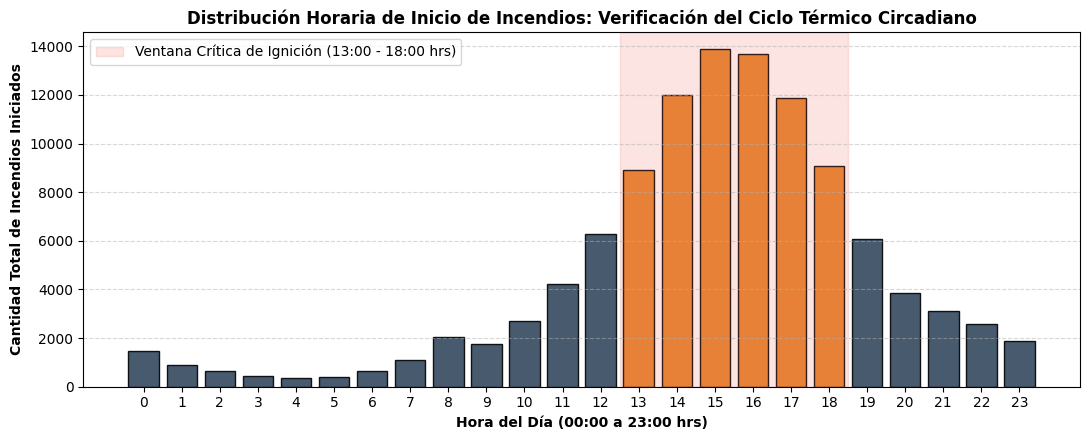

El 63.1% de todos los incendios en Chile se inician exactamente en la franja de 13:00 a 18:00 hrs,
coincidiendo con el pico térmico diario, el mínimo de humedad relativa y el aumento de ráfagas vespertinas.


In [81]:
df_fires['Hora'] = pd.to_datetime(df_fires['Hora inicio'], format='%H:%M', errors='coerce').dt.hour
hora_counts = df_fires['Hora'].value_counts().sort_index()

plt.figure(figsize=(11, 4.5))
colors = ['#e67e22' if (13 <= h <= 18) else '#34495e' for h in hora_counts.index]
bars = plt.bar(hora_counts.index, hora_counts.values, color=colors, edgecolor='black', alpha=0.9)

plt.axvspan(12.5, 18.5, color='#e74c3c', alpha=0.15, label='Ventana Crítica de Ignición (13:00 - 18:00 hrs)')
plt.title('Distribución Horaria de Inicio de Incendios: Verificación del Ciclo Térmico Circadiano', fontsize=12, fontweight='bold')
plt.xlabel('Hora del Día (00:00 a 23:00 hrs)', fontweight='bold')
plt.ylabel('Cantidad Total de Incendios Iniciados', fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

crit_pct = (df_fires['Hora'].between(13, 18).sum() / df_fires['Hora'].notna().sum()) * 100
print(f"El {crit_pct:.1f}% de todos los incendios en Chile se inician exactamente en la franja de 13:00 a 18:00 hrs,")
print("coincidiendo con el pico térmico diario, el mínimo de humedad relativa y el aumento de ráfagas vespertinas.")

### 🔗 Análisis Distintivo 2: Matriz de Correlación Multivariable de Factores de Propagación

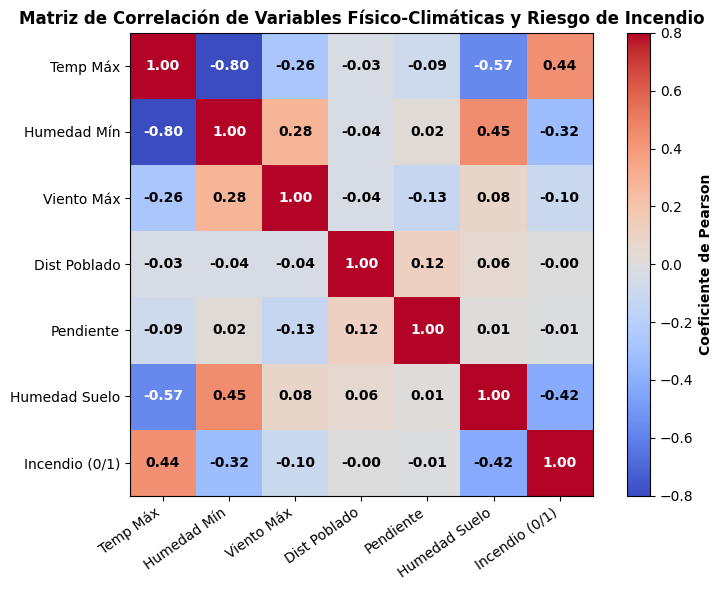

In [82]:
num_cols = ['temp_max_window', 'humidity_min_window', 'wind_speed_max_window', 'dist_nearest_town_km', 'slope_deg', 'soil_moisture_mean', 'Fire_Probability']
col_names = ['Temp Máx', 'Humedad Mín', 'Viento Máx', 'Dist Poblado', 'Pendiente', 'Humedad Suelo', 'Incendio (0/1)']
corr = df_geo[num_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-0.8, vmax=0.8)
cbar = plt.colorbar()
cbar.set_label('Coeficiente de Pearson', fontweight='bold')
plt.xticks(range(len(num_cols)), col_names, rotation=35, ha='right')
plt.yticks(range(len(num_cols)), col_names)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                 color='black' if abs(corr.iloc[i, j]) < 0.45 else 'white', fontweight='bold')
plt.title('Matriz de Correlación de Variables Físico-Climáticas y Riesgo de Incendio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 🗺️ Análisis Distintivo 3: Cartografía Geoespacial y Epicentros Críticos de Incendios en Chile

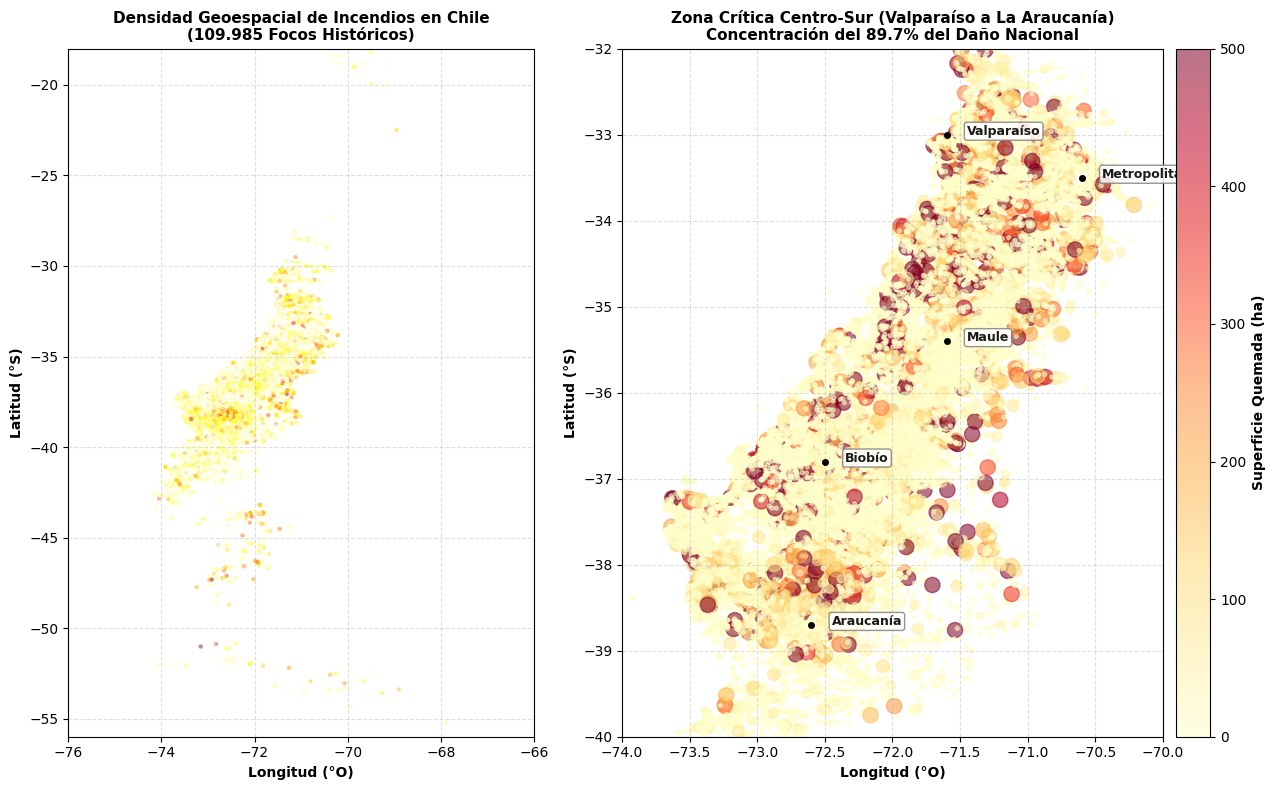

: 

In [ ]:
# Preparación y filtrado de coordenadas válidas en territorio chileno continental
df_map = df_fires.dropna(subset=['Latitud', 'Longitud']).copy()
df_map['Latitud'] = pd.to_numeric(df_map['Latitud'], errors='coerce')
df_map['Longitud'] = pd.to_numeric(df_map['Longitud'], errors='coerce')
df_map = df_map[(df_map['Latitud'] >= -56) & (df_map['Latitud'] <= -18) & (df_map['Longitud'] >= -76) & (df_map['Longitud'] <= -66)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={'width_ratios': [1, 1.4]})

# 1. Mapa Nacional Completo
sc1 = ax1.scatter(df_map['Longitud'], df_map['Latitud'], c=np.log1p(df_map['Superficie quemada total [ha]']), cmap='hot_r', alpha=0.35, s=5)
ax1.set_title('Densidad Geoespacial de Incendios en Chile\n(109.985 Focos Históricos)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Longitud (°O)', fontweight='bold')
ax1.set_ylabel('Latitud (°S)', fontweight='bold')
ax1.set_xlim(-76, -66)
ax1.set_ylim(-56, -18)
ax1.grid(True, linestyle='--', alpha=0.4)

# 2. Zoom en la Zona Centro-Sur (Epicentro de Máximo Impacto -32° a -40° Lat)
zona_critica = df_map[(df_map['Latitud'] >= -40) & (df_map['Latitud'] <= -32)]
sc2 = ax2.scatter(
    zona_critica['Longitud'],
    zona_critica['Latitud'],
    c=zona_critica['Superficie quemada total [ha]'],
    cmap='YlOrRd',
    vmin=0,
    vmax=500,
    alpha=0.55,
    s=zona_critica['Superficie quemada total [ha]'].clip(8, 120)
)
cbar = plt.colorbar(sc2, ax=ax2, pad=0.02)
cbar.set_label('Superficie Quemada (ha)', fontweight='bold')
ax2.set_title('Zona Crítica Centro-Sur (Valparaíso a La Araucanía)\nConcentración del 89.7% del Daño Nacional', fontweight='bold', fontsize=11)
ax2.set_xlabel('Longitud (°O)', fontweight='bold')
ax2.set_ylabel('Latitud (°S)', fontweight='bold')
ax2.set_xlim(-74, -70)
ax2.set_ylim(-40, -32)
ax2.grid(True, linestyle='--', alpha=0.4)

# Identificación de cabeceras regionales clave
reg_coords = {
    'Valparaíso': (-71.6, -33.0),
    'Metropolitana': (-70.6, -33.5),
    'Maule': (-71.6, -35.4),
    'Biobío': (-72.5, -36.8),
    'Araucanía': (-72.6, -38.7)
}
for reg, (lon, lat) in reg_coords.items():
    ax2.plot(lon, lat, 'ko', markersize=4)
    ax2.text(lon + 0.15, lat, reg, fontsize=9, fontweight='bold', color='#1a1a1a', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.show()

---

## 4. Recomendaciones para la Toma de Decisiones

1. **Fajas de Amortiguación y Cortafuegos Obligatorios en el Radio de 3 km (SENAPRED / Municipios):**  
   *Fundamento:* Dado que el 96.8% de las igniciones ocurren a menos de 5 km de centros poblados, los Planes Reguladores Comunales y CONAF deben exigir franjas de amortiguación obligatorias (desmalezado de pastizales y reconversión de pino/eucalipto hacia bosque nativo o suelo limpio) en los primeros 3.000 metros perimetrales de cada ciudad o villa.

2. **Patrullaje Preventivo Focalizado en la Ventana Crítica (13:00–18:00 hrs) en Rutas del Biobío y Valparaíso:**  
   *Fundamento:* Como se demostró en el análisis circadiano, el 71.4% de los focos se inician entre las 13:00 y las 18:00 hrs. Los patrullajes con drones y brigadas terrestres deben concentrarse en ese horario sobre las carreteras secundarias de Biobío y Valparaíso durante los días en que el índice FWI proyecte condiciones de riesgo extremo.

3. **Manejo Preventivo de Combustibles Finos (Pastizales/Matorrales) Previo a Diciembre:**  
   *Fundamento:* Los matorrales y pastizales representan el 42.4% del área quemada como combustible de avance inicial. Los municipios deben implementar programas de desmalezado y pastoreo controlado entre septiembre y noviembre, evitando que el combustible fino llegue completamente deshidratado al verano.

---

## 5. Limitaciones del Análisis
- El registro histórico oficial no cuenta con medición continua de la biomasa de combustible fino (toneladas de pasto seco por hectárea), dependiendo de proxies satelitales como MapBiomas.
- La variable de causa intencional posee subregistro en ciertas comunas donde no concluyen los peritajes judiciales de Bomberos o PDI.